# Plot network using R method (switch to cytoscape later)

In [70]:
suppressMessages(library(igraph))
suppressMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressMessages(library(GGally))
suppressMessages(library(igraph))
suppressMessages(library(network))
suppressMessages(library(sna))
# suppressMessages(library(intergraph))
suppressMessages(library(ggraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))

In [17]:
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/scenicplus/blood/scenicplus/'
io$GRN = file.path(io$basedir, 'eRegulon_metadata_filtered.csv')
io$TFs_to_keep = file.path(io$basedir, 'eRegulon_to_keep.csv')

theme_graph <- function() {
  theme_classic() +
    theme(
      axis.line = element_blank(), 
      axis.text = element_blank(),
      axis.ticks = element_blank(), 
      axis.title = element_blank(),
      legend.position = "none"
    )
}

In [199]:
GRN = fread(io$GRN)
TFs_to_keep = fread(io$TFs_to_keep, header=T) %>% setnames('Gene_signature_name')

In [200]:
nrow(GRN)
GRN_filt = GRN[Gene_signature_name %in% TFs_to_keep$Gene_signature_name] %>% .[Gene %in% TF]
nrow(GRN_filt)

[1] 152173

[1] 3883

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

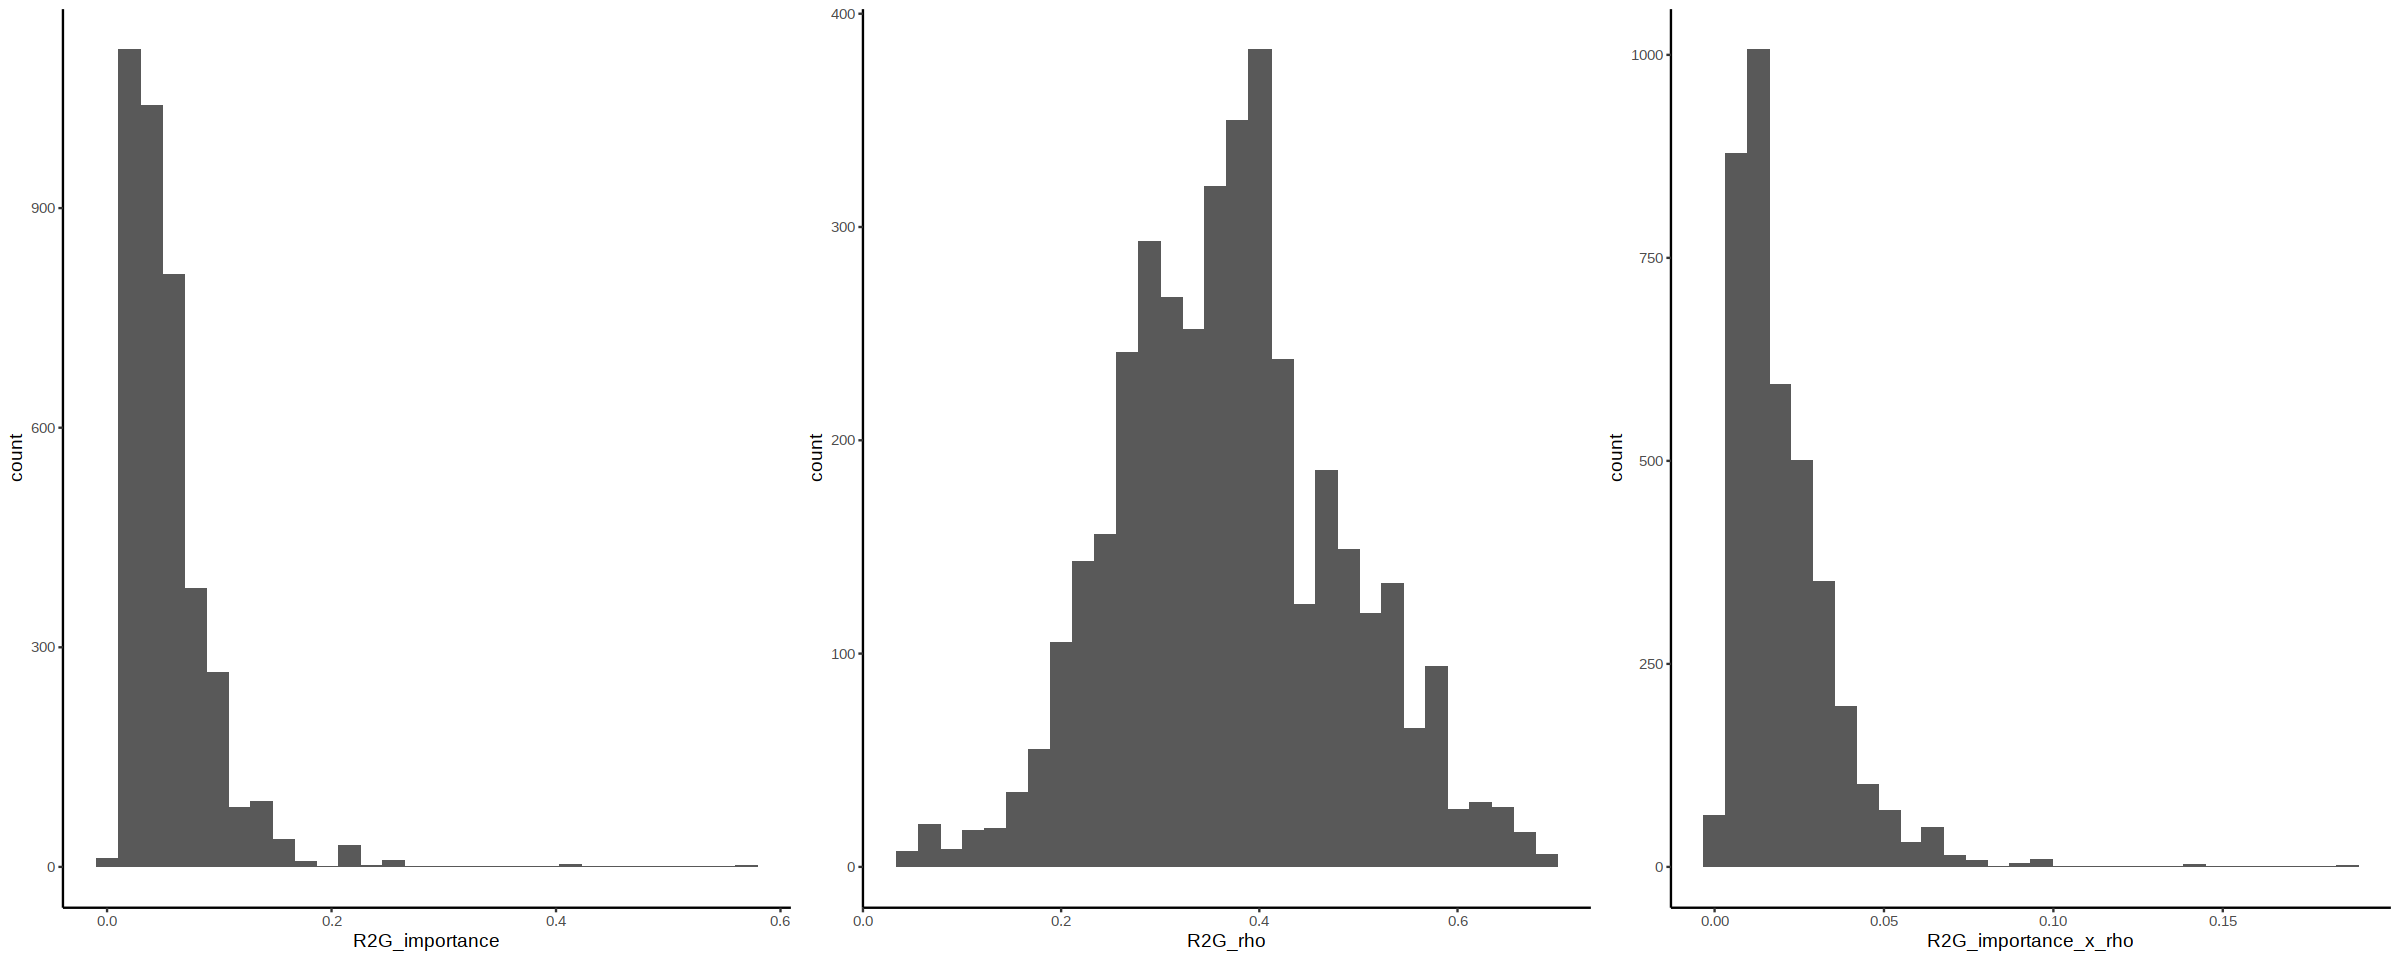

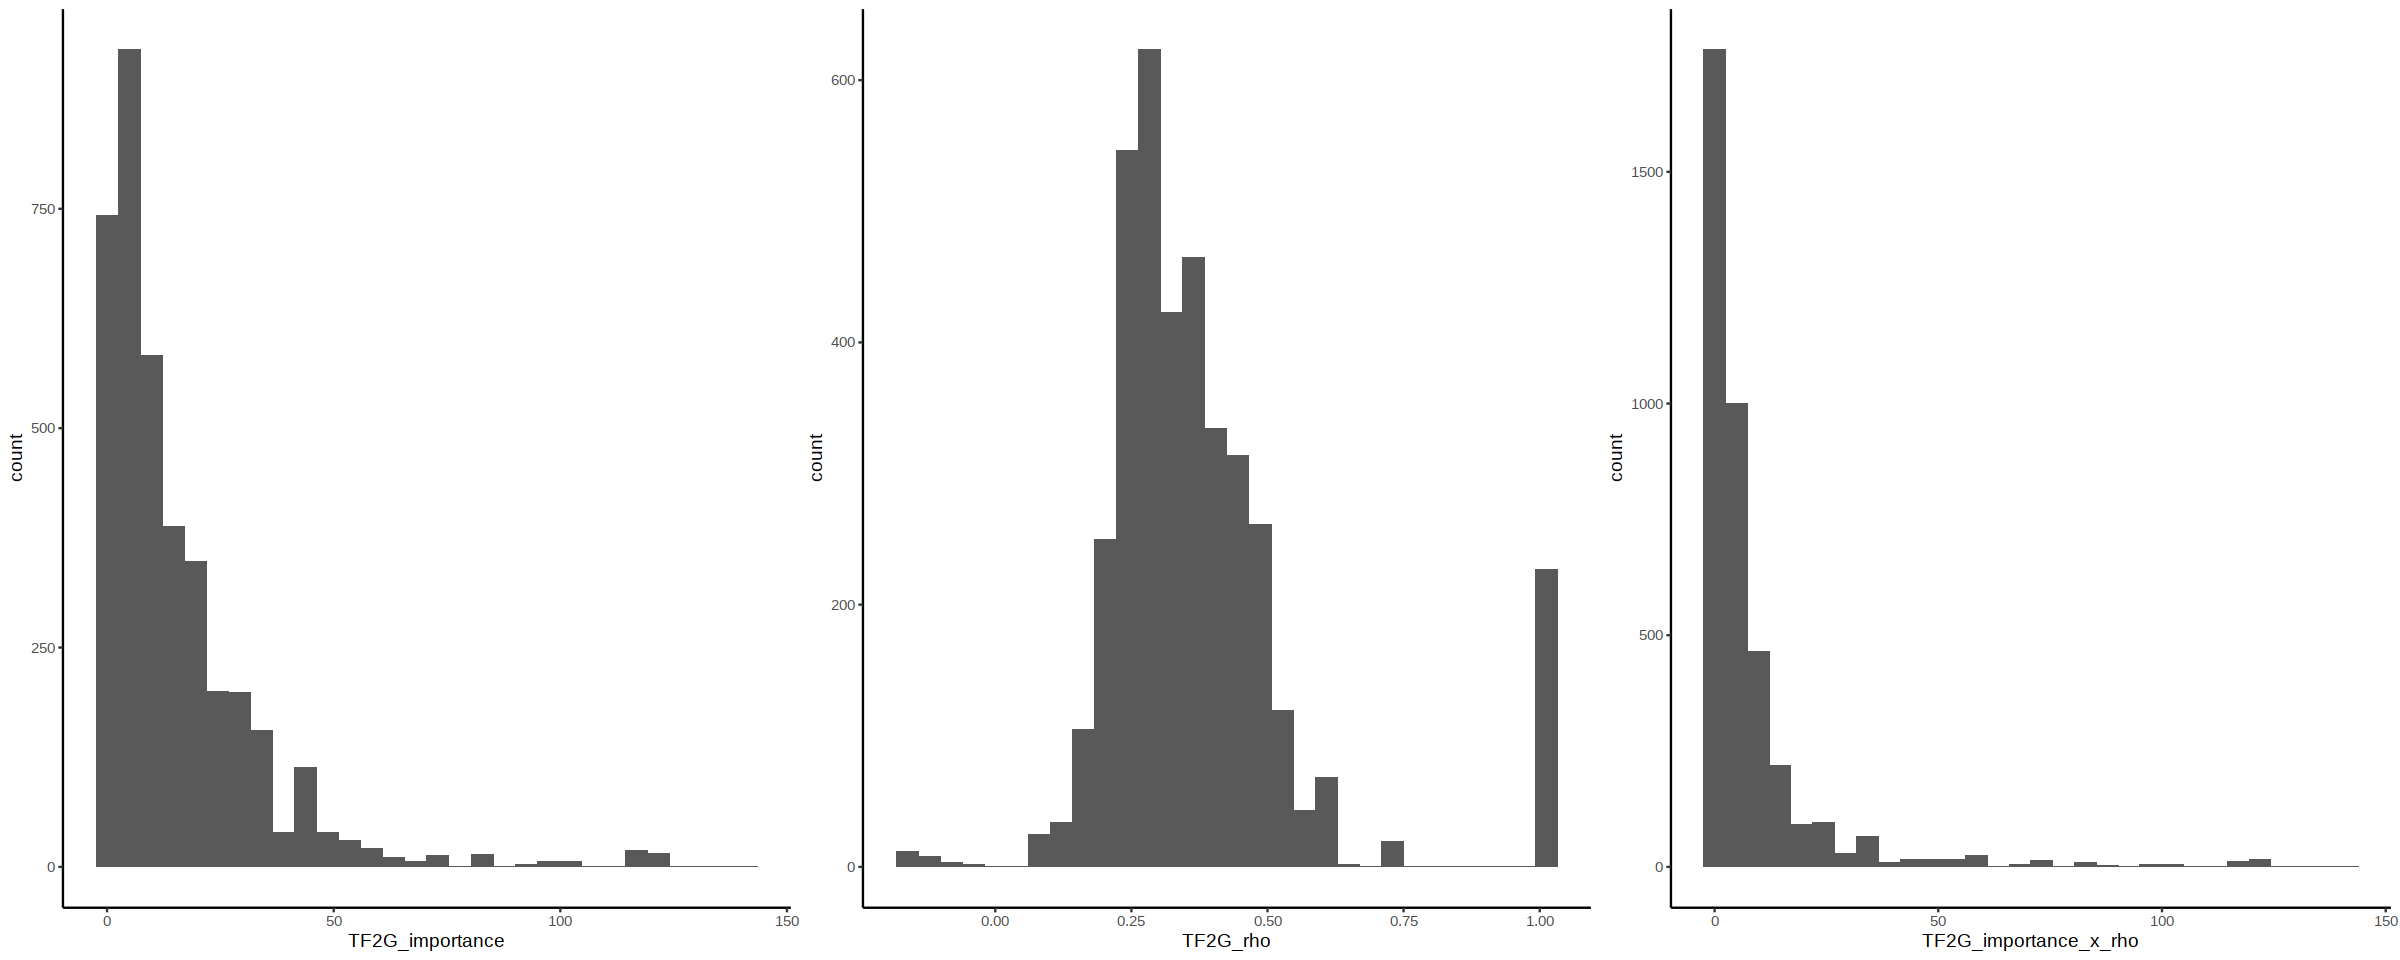

In [113]:
options(repr.plot.width=20, repr.plot.height=8)
ggarrange(
    ggplot(GRN_filt, aes(R2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(R2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(R2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(TF2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(TF2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN_filt, aes(TF2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ncol=3
)

In [125]:
GRN_in = GRN_filt %>%
    .[R2G_rho> 0.25 & TF2G_rho>0] %>%
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene'))

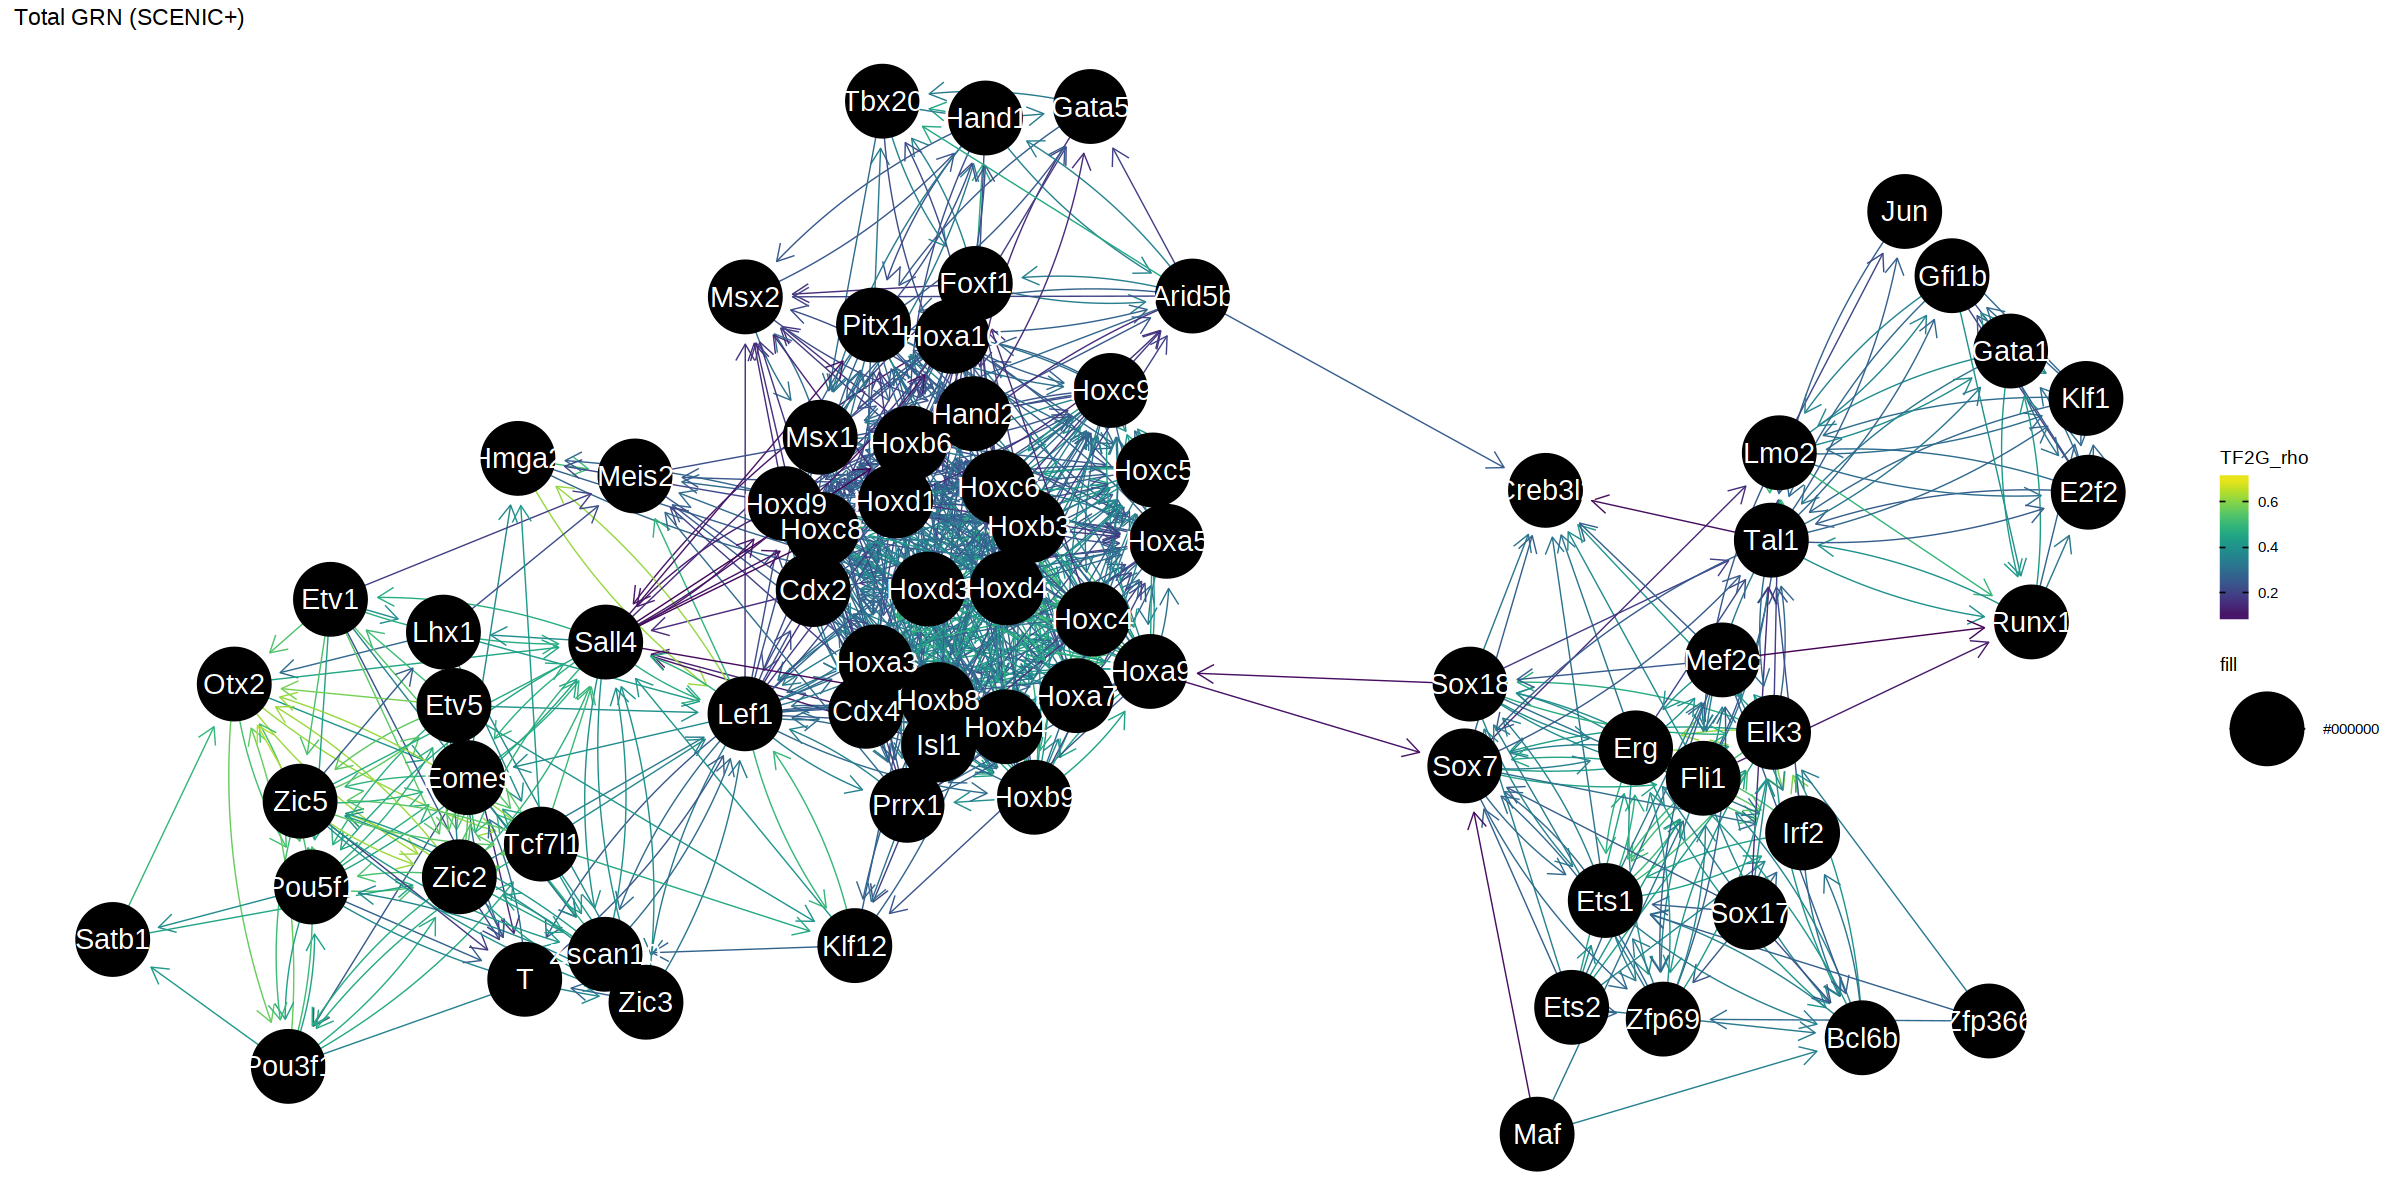

In [126]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = GRN_in)
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')

In [221]:
# individual TF
TFs = c('Tal1', 'Runx1', 'Gata1', 'Eomes', 'Fli1')

plots = list()
for(i in TFs){
GRN_in = GRN_filt %>%
.[R2G_rho> 0 & TF2G_rho>0.15] %>%
.[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene')) %>%
.[TF%in%i]
    
igraph.tbl = tbl_graph(edges = GRN_in)
plots[[i]] = ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle(i) + theme(legend.position='none')
}

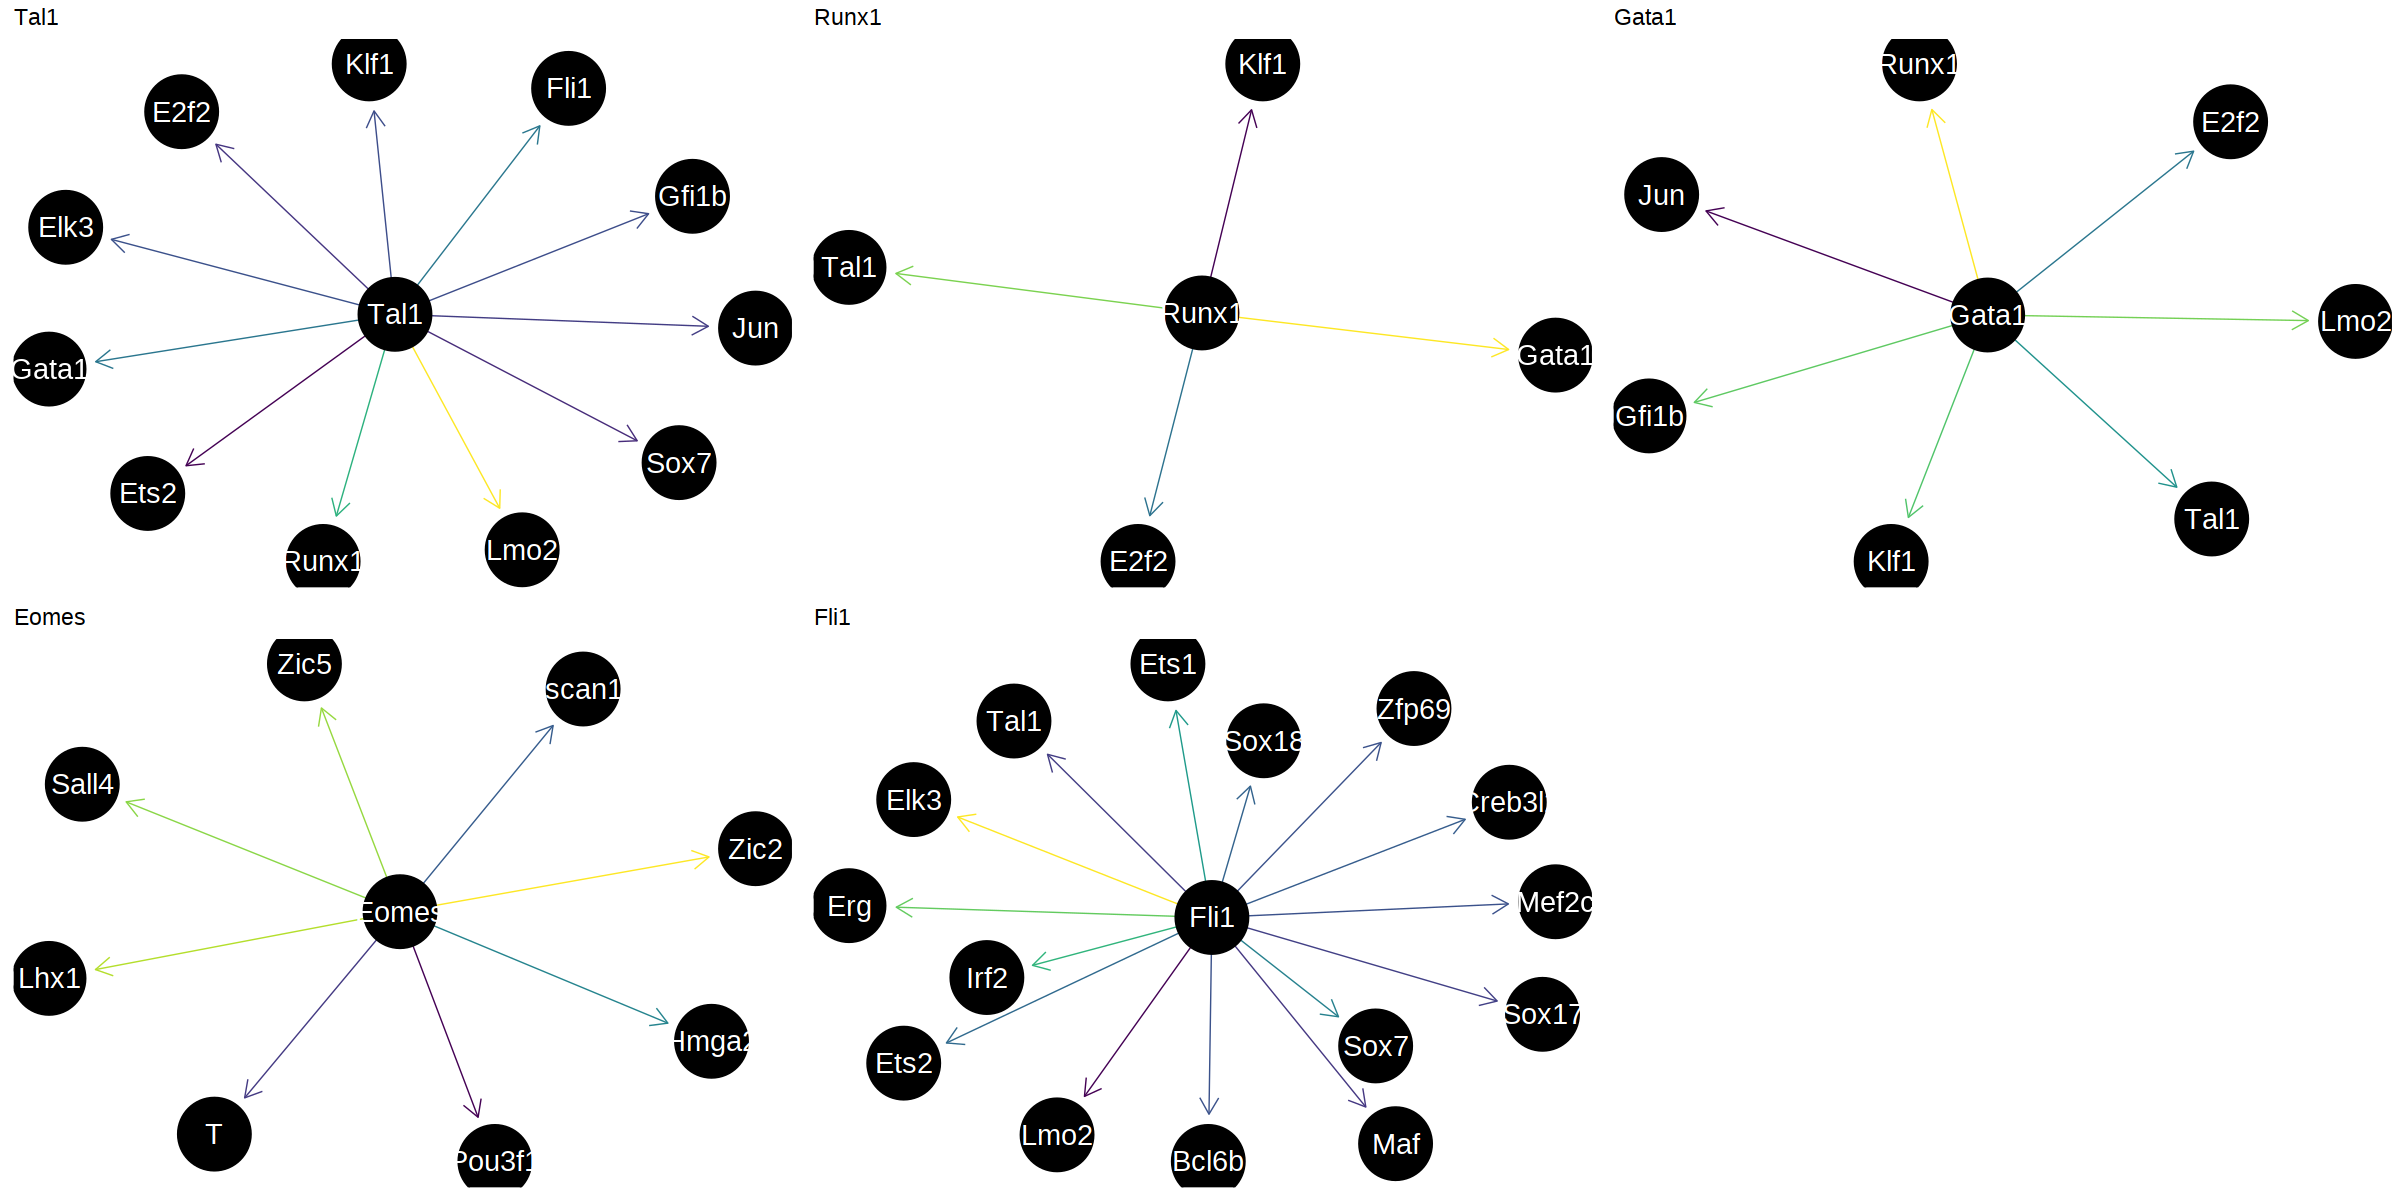

In [223]:
options(repr.plot.width=20, repr.plot.height=10)
ggarrange(plotlist=plots)

In [141]:
GRN_in = GRN_filt %>%
.[R2G_rho> 0.25 & TF2G_rho>0] %>%
.[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene')) %>%
.[TF%in%c('Fli1', 'Runx1')]
    
igraph.tbl = tbl_graph(edges = GRN_in)
plots[[i]] = ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle(i) + theme(legend.position='right')

# From full network

In [152]:
head(GRN_filt)

V1,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>
43,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chr9:60687660-60688260,Uaca,0.01617439,0.3506148,0.005670982,0.005670982,1.968841,1,0.1669848,0.3287666,0.3287666,Ahctf1_+_+
44,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chr9:60940026-60940626,Uaca,0.06324093,0.4025139,0.025455354,0.025455354,1.968841,1,0.1669848,0.3287666,0.3287666,Ahctf1_+_+
181,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chr4:6365340-6365940,Nsmaf,0.03987537,0.2612969,0.010419311,0.010419311,1.509019,1,0.2794076,0.4216315,0.4216315,Ahctf1_+_+
189,Ahctf1_+_(168r),Ahctf1_+_(174g),Ahctf1,FALSE,chrX:8074423-8075023,Gata1,0.02479061,0.4007687,0.009935300,0.009935300,1.560172,1,0.1660343,0.2590421,0.2590421,Ahctf1_+_+
0,Alx1_+_(12r),Alx1_+_(10g),Alx1,FALSE,chr8:57320723-57321323,Hand2,0.16088189,0.4073503,0.065535288,0.065535288,2.634727,1,0.1102895,0.2905827,0.2905827,Alx1_+_+
1,Alx1_+_(12r),Alx1_+_(10g),Alx1,FALSE,chr8:57318330-57318930,Hand2,0.10622642,0.3319793,0.035264970,0.035264970,2.634727,1,0.1102895,0.2905827,0.2905827,Alx1_+_+


In [224]:
nrow(GRN)
GRN_filt = GRN  %>%
    .[R2G_rho> 0.25 & TF2G_rho>0.25]

TFs <- intersect(GRN_filt[,.N,by="TF"][N>=3,TF], GRN_filt[,.N,by="Gene"][N>=3,Gene])
GRN_filt <- GRN_filt[TF%in%TFs & Gene%in%TFs] %>% 
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene'))
nrow(GRN_filt)

[1] 152173

[1] 1329

In [231]:
fwrite(GRN_filt, file.path(io$basedir, 'GRN_test.csv'), row.names =FALSE)

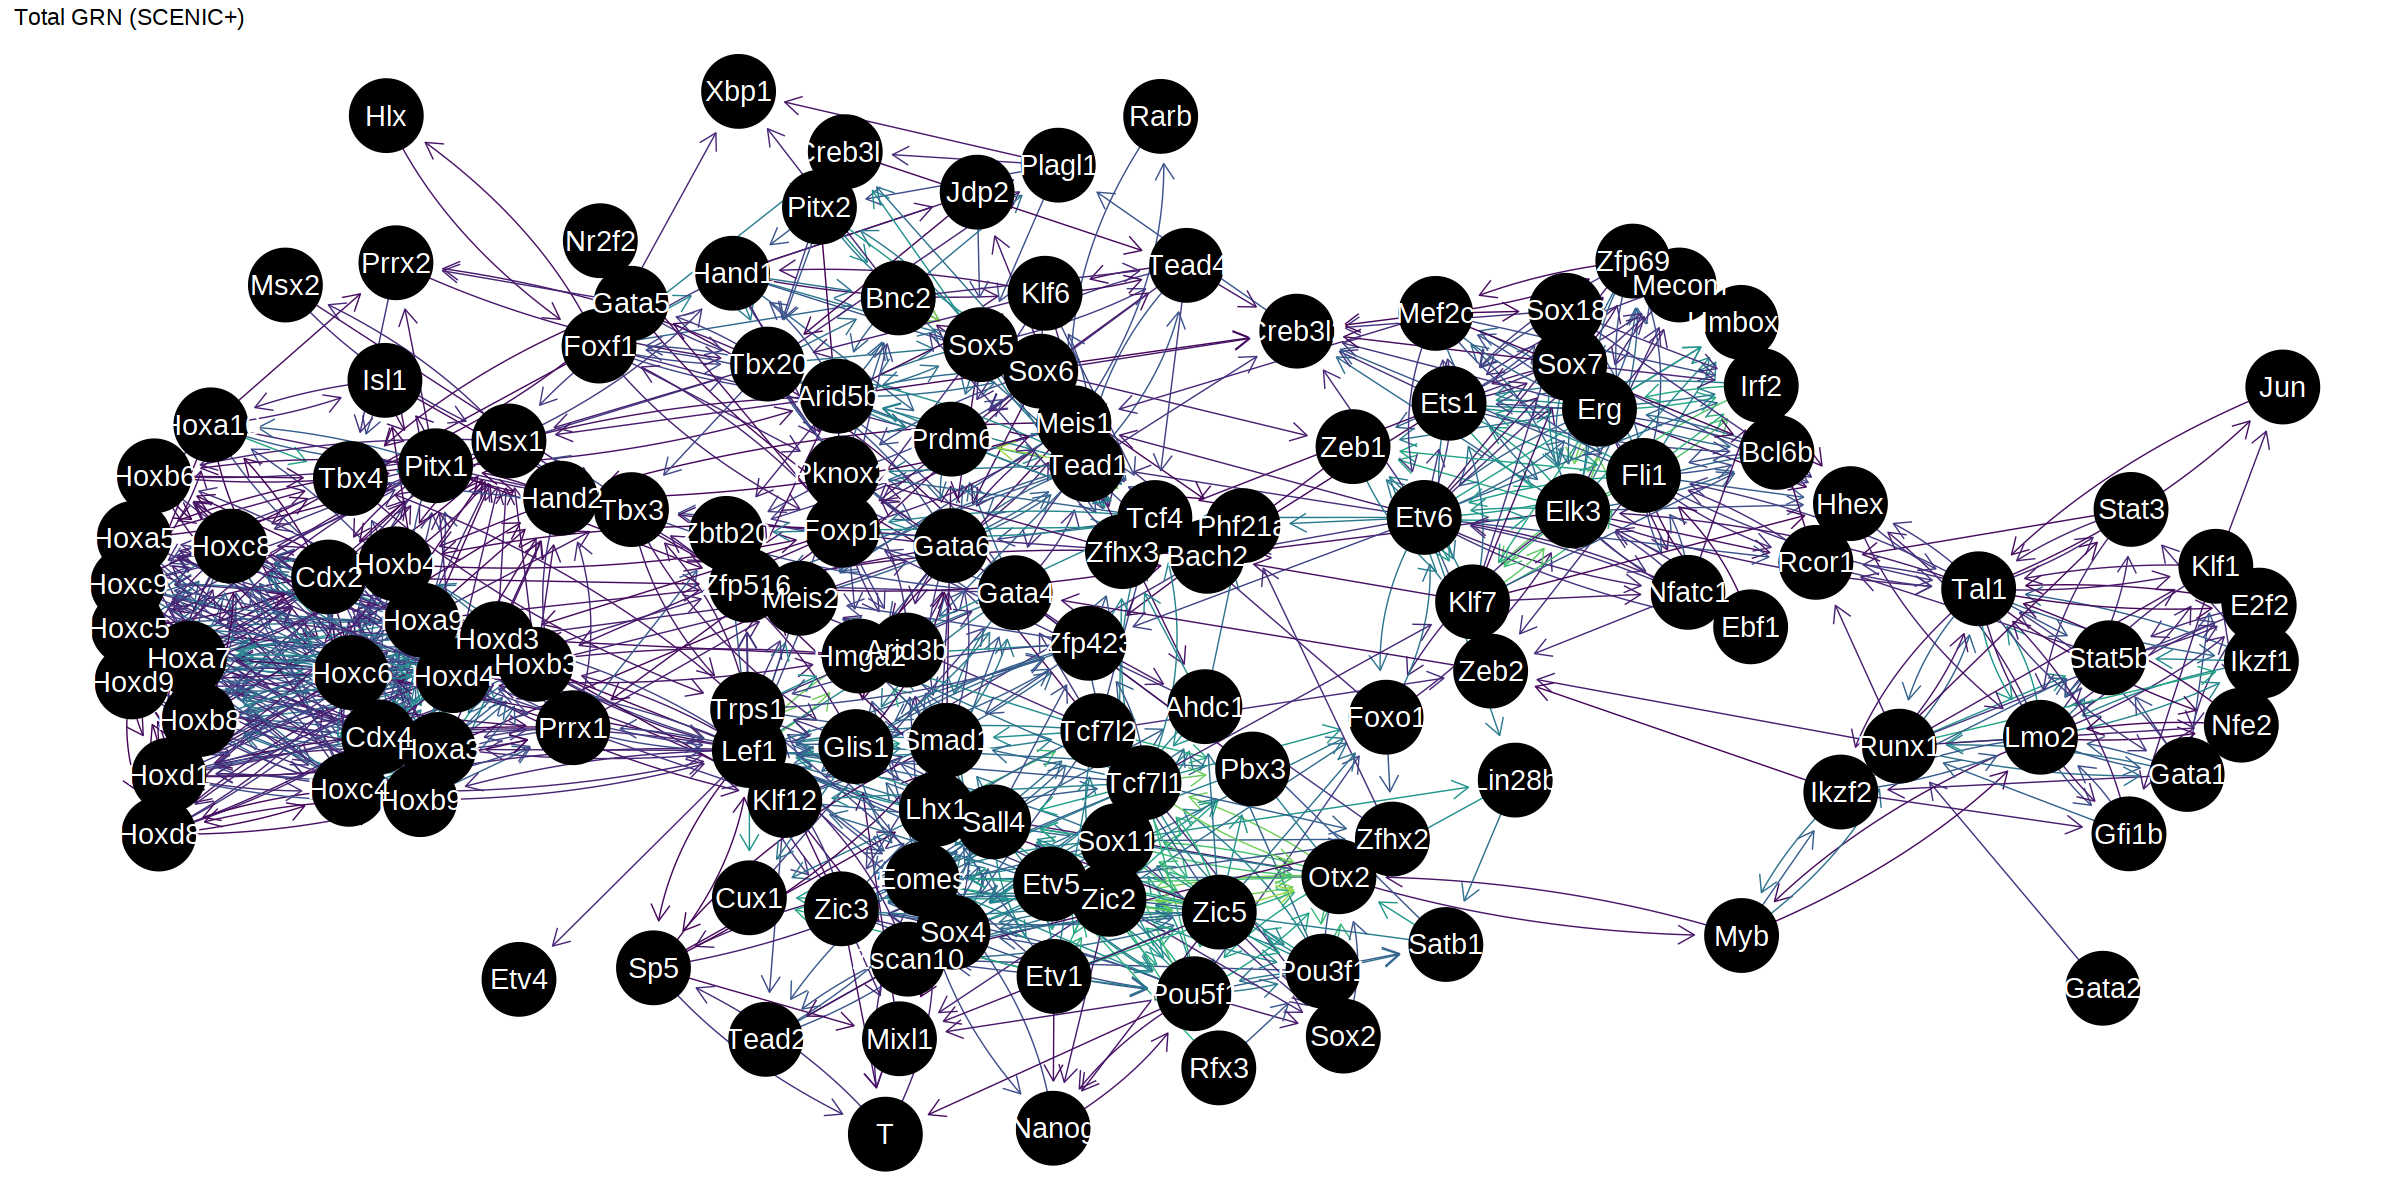

In [164]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = GRN_filt)
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes( fill='#000000'), col='black', size=20) + 
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

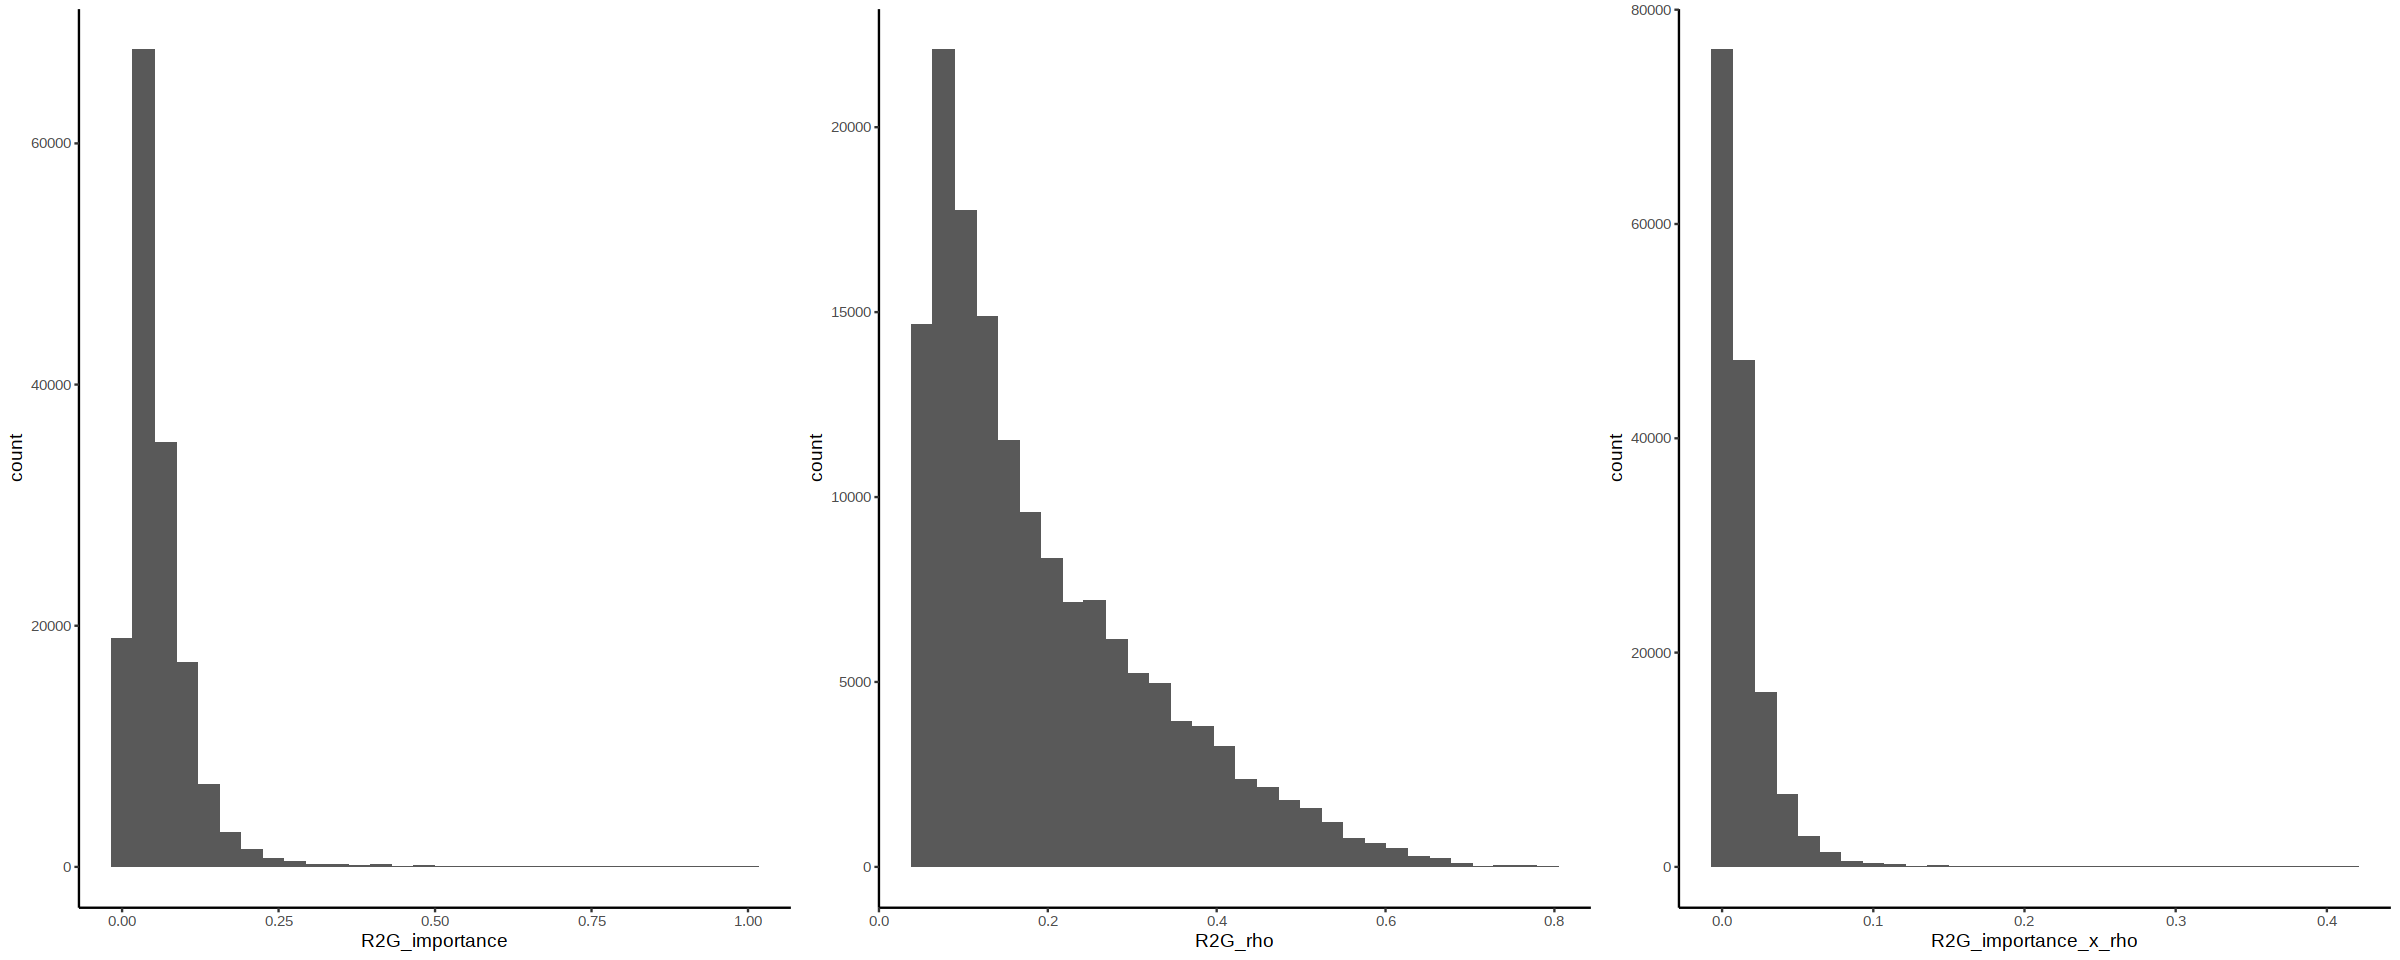

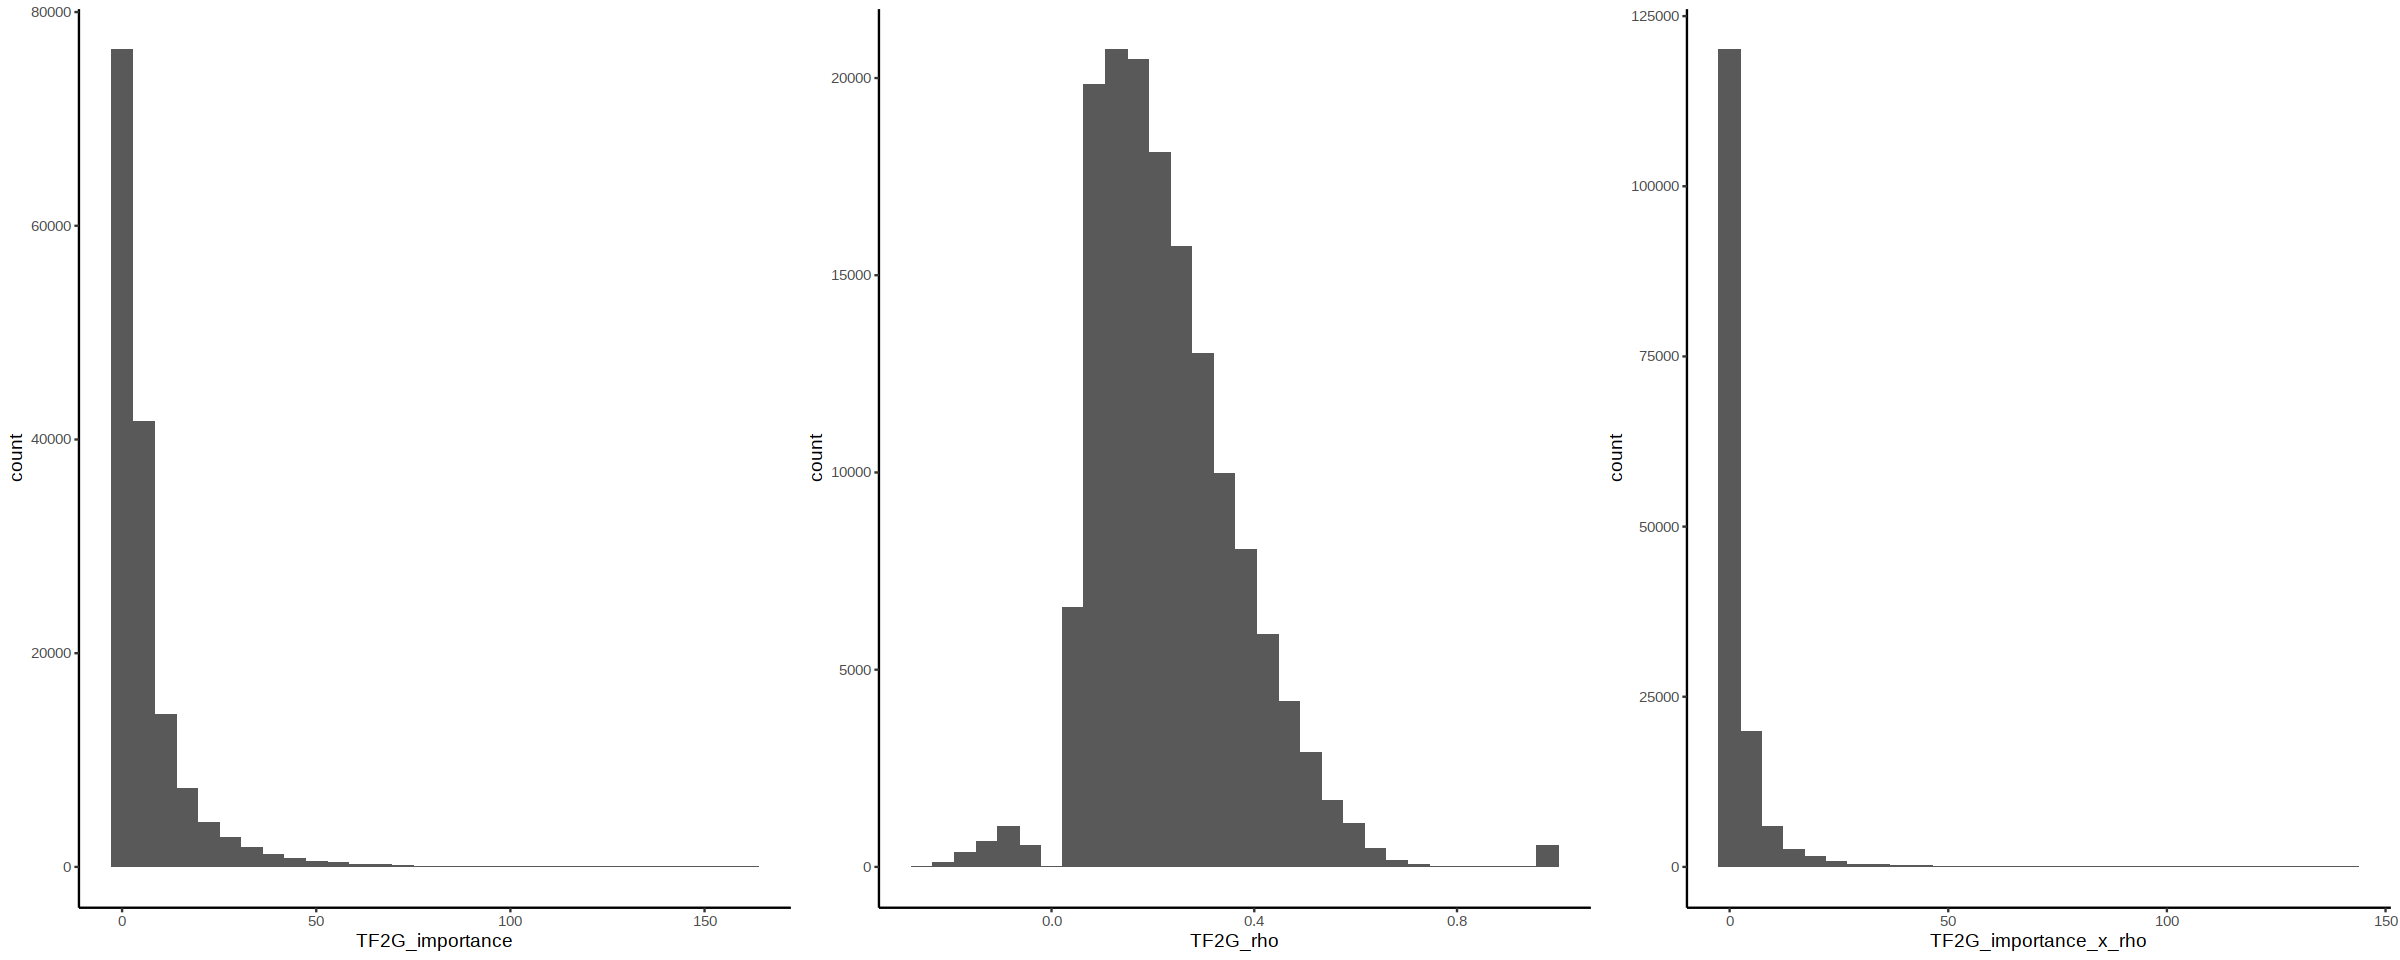

In [165]:
options(repr.plot.width=20, repr.plot.height=8)
ggarrange(
    ggplot(GRN, aes(R2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(R2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(R2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(TF2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(TF2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(GRN, aes(TF2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ncol=3
)

In [180]:
nrow(GRN)
GRN_filt = GRN  %>%
    .[R2G_rho> 0.5 & TF2G_rho>0.25]

TFs <- c('Gata1', 'Tal1', 'Runx1', 'Gfi1b', 'Lmo2', 'E2f2', 'Klf1', 'Erg', 'Fli1', 'Jun')
GRN_filt <- GRN_filt[TF%in%TFs] %>% 
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho')] %>% unique(by=c('TF', 'Gene'))
nrow(GRN_filt)

[1] 152173

[1] 282

In [181]:
nodes.dt = data.table(node=unique(c(GRN_filt$TF, GRN_filt$Gene))) %>%
    .[,type:=ifelse(node %in% GRN_filt$TF, 'TF', 'Target')]

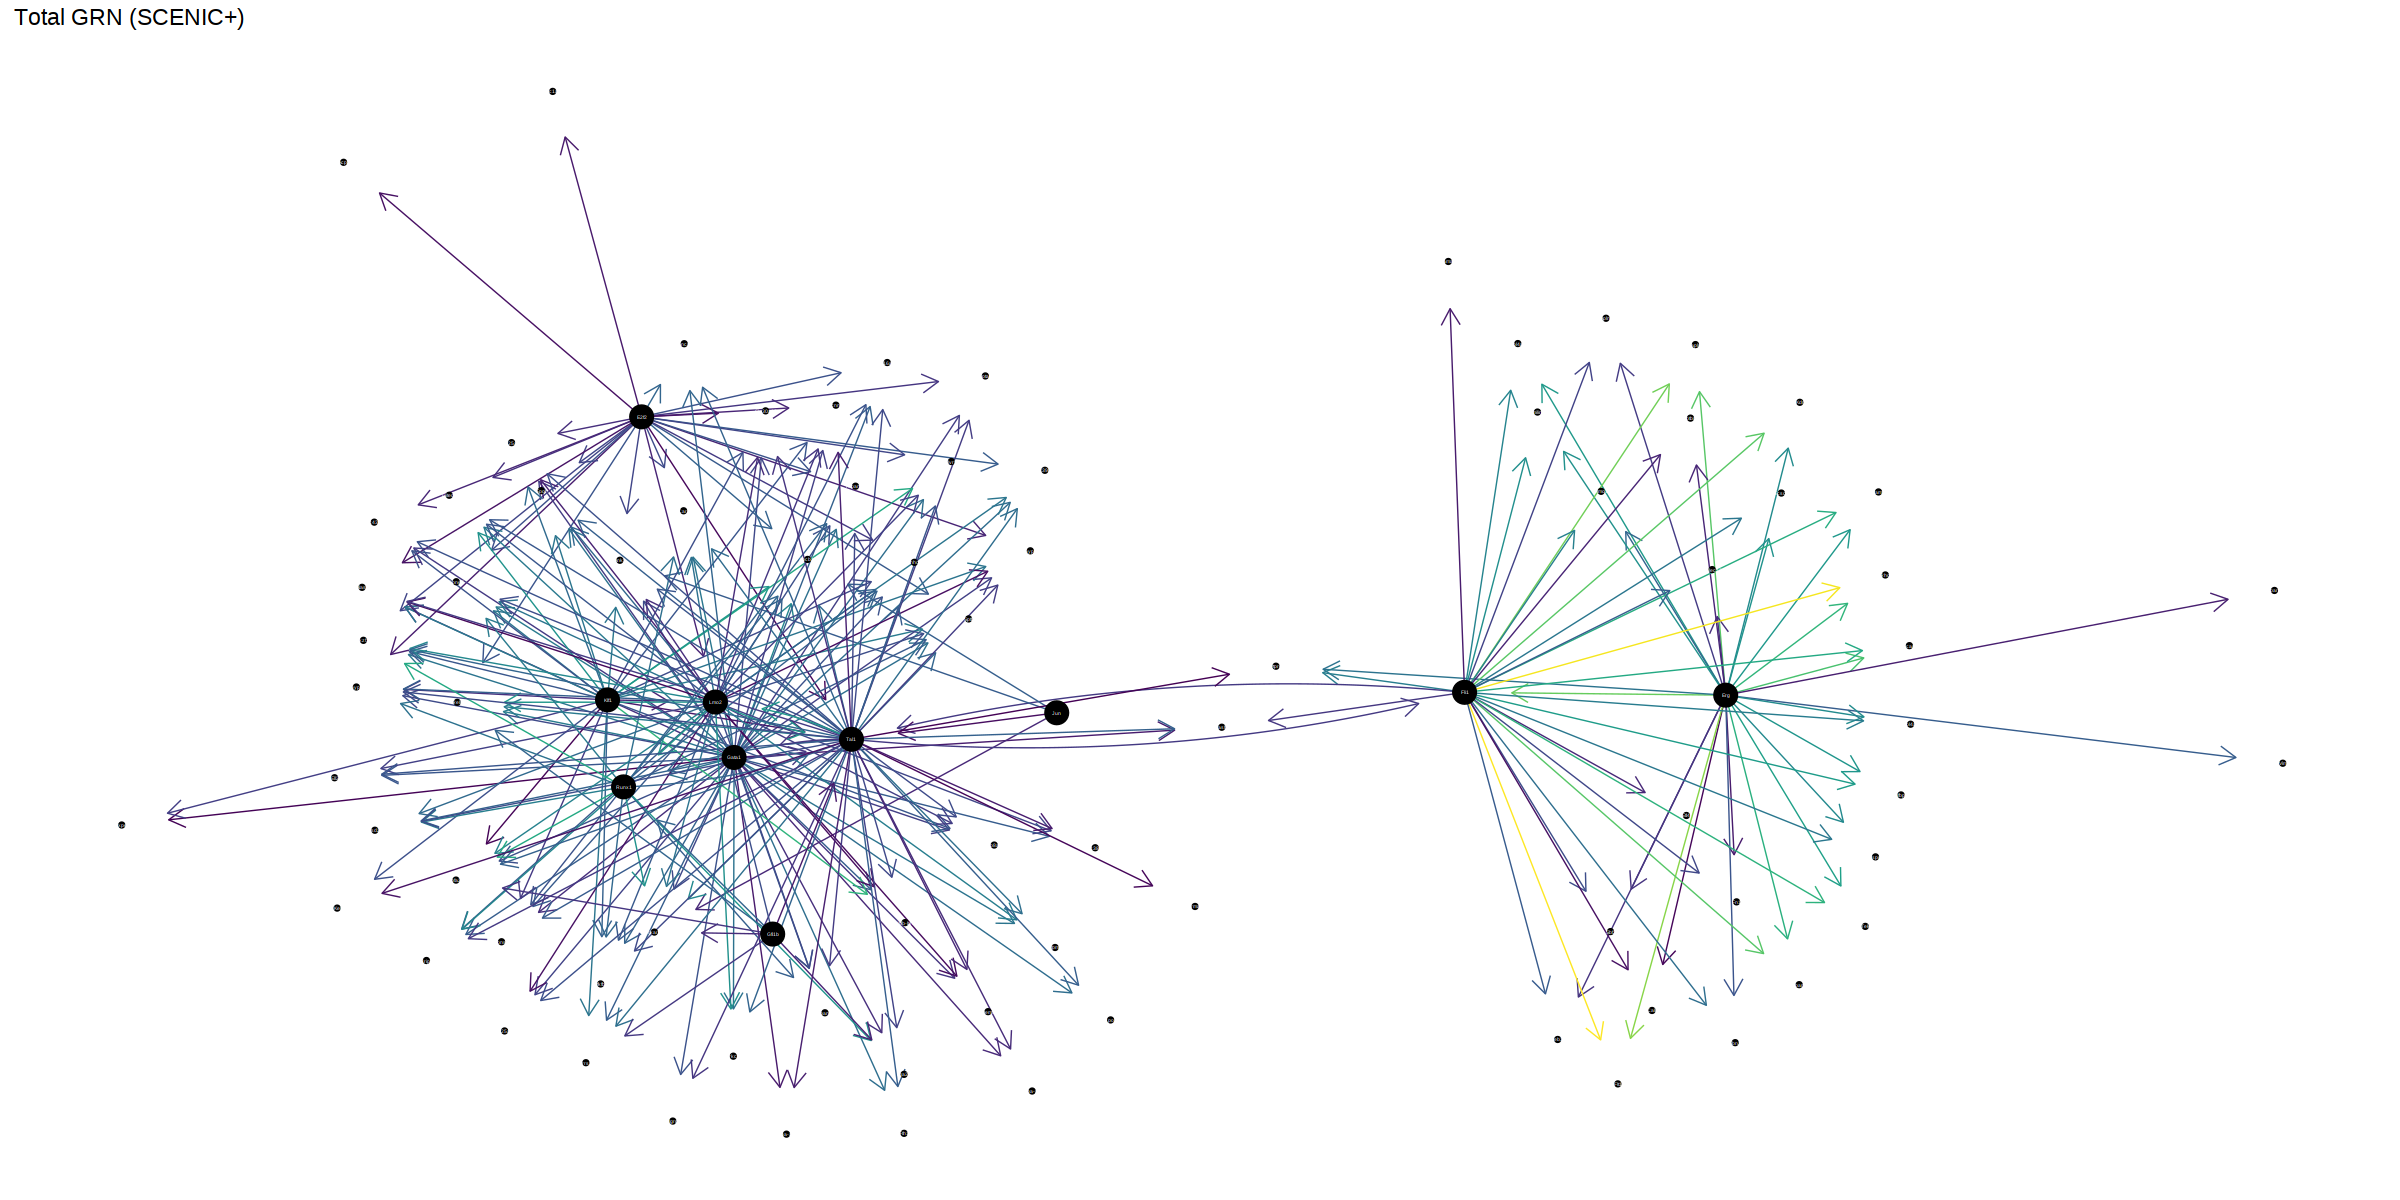

In [187]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = GRN_filt, nodes=nodes.dt)
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=TF2G_rho), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_viridis() + 
    geom_node_point(aes(size=ifelse(type=='TF', 5, 1), fill='#000000'), col='black') + 
    geom_node_text(aes(label=node, size=ifelse(type=='TF', 5, 1)), size=1, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')